# Trabajo práctico Nº7: Medio interestelar

Notebook creada por Tomás Ansin (2021) y modificada por G. Ferrero (2022)

### 1. a) Descargue del Classroom el archivo $\texttt{polarizacion.dat}$ que contiene los datos de polarización en la banda R de un conjunto de estrellas en el campo del *blazar* 1ES 1959+650 (ver [Sosa et al. 2017; S17](https://ui.adsabs.harvard.edu/abs/2017A%26A...607A..49S)).
### b) Usando las ecuaciones (1), (2) y (3) de S17, calcule la polarización $(P)$ y el ángulo de polarización observado $(\theta_{obs})$.
### Tome en cuenta que es necesario corregir los ı́ndices de Stokes observados ($Q_{obs}$ y $U_{obs}$) por la polarización instrumental ($Q_{ins}$ y $U_{ins}$), de acuerdo a las relaciones
### $Q = Q_{obs} - Q_{ins}$
#### y
### $U = U_{obs} - U_{ins}$
### donde $Q_{ins} = 0.029\; \%$ y $U_{ins} = 0.015\: \%$.
### Lleve los ángulos de polarización observados al sistema estándar, aplicando la corrección
### $\theta_s = \theta_{obs} + \Delta\theta$,
### donde $\Delta\theta = 175.1^\circ$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from astropy.io import fits                        # en esta práctica usaremos algunas tareas de astropy 
from astropy.visualization import ZScaleInterval
plt.style.use('sisest.mplstyle')

In [55]:
# Importamos la tabla
#F=flujo. e=error. ###=ángulo(grad). O=ordinario, E=extraordinario
tpol = pd.read_csv('polarizacion.dat', sep='\s+', header=0, comment='#', index_col='est')
tpol.head()

,F000O,eF000O,F000E,eF000E,F225O,eF225O,F225E,eF225E,F450O,eF450O,F450E,eF450E,F675O,eF675O,F675E,eF675E
est,,,,,,,,,,,,,,,,
1,63339.99,169.1867,61979.75,165.5533,59185.40,163.5408,69313.04,178.7570,59548.88,164.5451,61562.24,164.4381,61293.30,163.7198,54397.06,155.3200
2,90987.65,201.1332,92944.80,205.4596,90718.48,200.5382,95376.17,202.0495,89120.63,197.0061,88626.74,195.9143,84734.56,195.1150,82210.98,189.3041
3,39820.62,135.7063,41050.94,136.1181,40698.08,134.9480,41580.17,137.8729,38958.57,132.7684,39200.53,133.5930,36575.31,128.0153,37268.02,130.4398
4,453849.30,459.8270,455122.40,461.1169,452673.60,458.6359,455546.70,461.5468,464628.60,470.7483,453932.50,459.9113,465767.30,471.9020,462519.30,468.6112
5,115955.90,224.2860,117528.40,227.3276,117293.10,226.8725,119420.60,230.9876,110972.80,224.8690,110527.00,223.9656,104176.80,211.0979,102750.40,217.6715


In [56]:
# calculamos las expresiones R_Q^2 y R_U^2
rq2 = (tpol.F000O / tpol.F000E) / (tpol.F450O / tpol.F450E)
ru2 = (tpol.F225O / tpol.F225E) / (tpol.F675O / tpol.F675E)

# luego R_Q y R_U
rq = np.sqrt(rq2)
ru = np.sqrt(ru2)

# después los índices de Stokes observados: Q_obs y U_obs
qobs = (rq-1)/(rq+1)
uobs = (ru-1)/(ru+1)

# ahora corregimos por la polarización instrumental (recordemos que está dada en porcentajes)
qins = 0.029/100.
uins = 0.015/100.
qcorr = qobs - qins
ucorr = uobs - uins

# y por último calculamos la polarización (recordemos que suele expresarse en porcentaje)
p = np.sqrt(qcorr**2 + ucorr**2) 

# ahora calculamos el ángulo de polarización y lo pasamos al sistema estándar (Norte = 0°, Este = 90°)
# atención a calcular el arcotangente usando la función adecuada, que elija bien los cuadrantes
thetaobs = 0.5*np.arctan2(ucorr,qcorr)*180./np.pi
dtheta = 175.1
thetastd = thetaobs + dtheta

# p en porcentaje. el que tiene p=7.06 es el blazar, es una polarización muy grande.
# Agregamos estos datos a la tabla
tpol['Q'] = qcorr
tpol['U'] = ucorr
tpol['P'] = p*100.       # (en porcentaje)
tpol['theta'] = thetastd
tpol

,F000O,eF000O,F000E,eF000E,F225O,eF225O,F225E,eF225E,F450O,eF450O,F450E,eF450E,F675O,eF675O,F675E,eF675E,Q,U,P,theta
est,,,,,,,,,,,,,,,,,,,,
1,63339.99,169.18670,61979.75,165.55330,59185.40,163.54080,69313.04,178.75700,59548.88,164.54510,61562.24,164.43810,61293.30,163.71980,54397.06,155.32000,0.013449,-0.069369,7.066052,135.586191
2,90987.65,201.13320,92944.80,205.45960,90718.48,200.53820,95376.17,202.04950,89120.63,197.00610,88626.74,195.91430,84734.56,195.11500,82210.98,189.30410,-0.007000,-0.020223,2.140003,120.553923
3,39820.62,135.70630,41050.94,136.11810,40698.08,134.94800,41580.17,137.87290,38958.57,132.76840,39200.53,133.59300,36575.31,128.01530,37268.02,130.43980,-0.006349,-0.000820,0.640201,88.779793
4,453849.30,459.82700,455122.40,461.11690,452673.60,458.63590,455546.70,461.54680,464628.60,470.74830,453932.50,459.91130,465767.30,471.90200,462519.30,468.61120,-0.006813,-0.003481,0.765056,98.633197
5,115955.90,224.28600,117528.40,227.32760,117293.10,226.87250,119420.60,230.98760,110972.80,224.86900,110527.00,223.96560,104176.80,211.09790,102750.40,217.67150,-0.004664,-0.008090,0.933845,115.119175
6,429787.20,435.44800,433760.50,439.47360,425185.00,430.78520,430529.40,436.20000,435766.30,441.50580,427105.90,432.73140,425207.30,430.80790,425994.30,431.60510,-0.007609,-0.002811,0.811145,95.236323
7,20050.30,97.87840,20367.27,97.54980,20299.36,97.22453,20844.01,99.83317,19623.37,95.79426,19396.03,96.47099,18767.29,95.07239,18740.90,94.93868,-0.007124,-0.007121,1.007299,107.593218
8,67199.14,235.20010,65841.07,169.80290,66380.72,232.33560,67004.23,172.80260,64024.66,229.98630,64469.44,172.20350,62457.09,230.10810,61341.46,163.84840,0.006545,-0.006993,0.957800,151.651655
9,19465.41,184.66770,18977.09,94.38730,19228.44,187.73280,19181.52,95.40410,18841.49,190.89650,18561.86,94.03168,18363.64,186.05510,17208.79,90.34735,0.002324,-0.015776,1.594622,134.289220


In [ ]:
img_archivo ='vonC_0053_PRO.fits'     # asignamos a una variable el nombre del archivo fits que contiene la imagen
with fits.open(img_archivo) as hdul:  # Dentro del bloque with abrimos la imagen
    hdul.info()                       # miramos las HDU que contiene
    hdr = hdul[0].header              # Extraemos el header
    data = hdul[0].data               # y la imagen
    
hdr

Filename: vonC_0053_PRO.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     251   (1024, 1024)   float32   


SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 1024 / Axis length                                    
NAXIS2  =                 1024 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2012-05-27T19:59:39' / Date FITS file was generated                  
IRAF-TLM= '2012-06-23T15:37:06' / Time of last modification                     
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy and
COMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.
COMMENT   Contact the NASA Science Office of Standards and Technology for the   
COMMENT   FITS Definition do

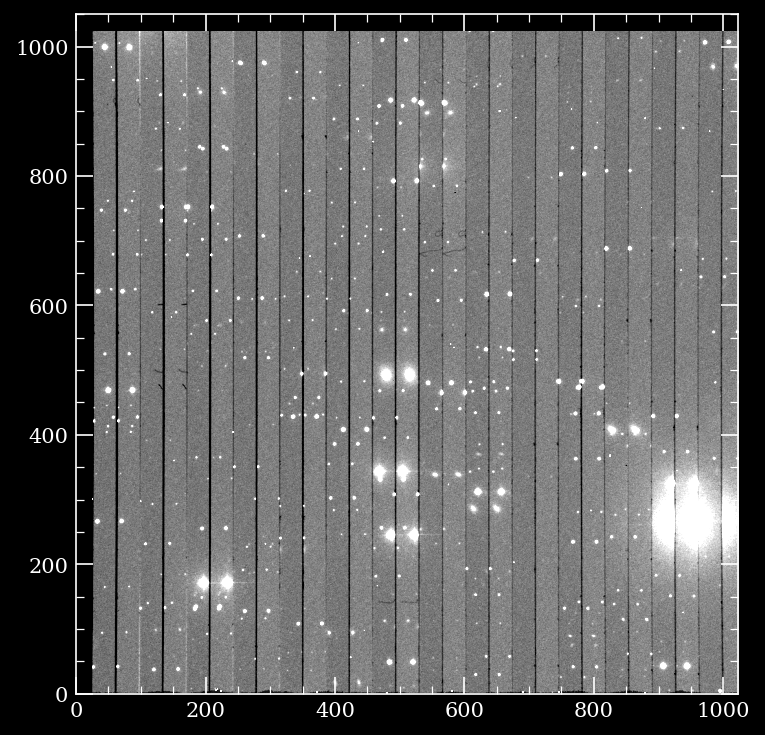

In [ ]:
# Imagen del campo tomada con el polarímetro

# El intervalo a representar (mínimo, máximo de brillo) estára definido por la función ZScaleInterval(), basada en la escala del DS9
interval = ZScaleInterval()

# Calculamos los valores de intensidad mínima y máxima y los guardamos en variables 
valor_min, valor_max = interval.get_limits(data) #(data es la imagen como matriz)

# ahora graficamos usando un mapa de color en gris
fig = plt.figure(figsize=(6,6), dpi=150)
plt.imshow(data, 
           vmin = valor_min, 
           vmax = valor_max, 
           cmap='gray', origin='lower')

plt.ylim(0, 1050)
plt.show()

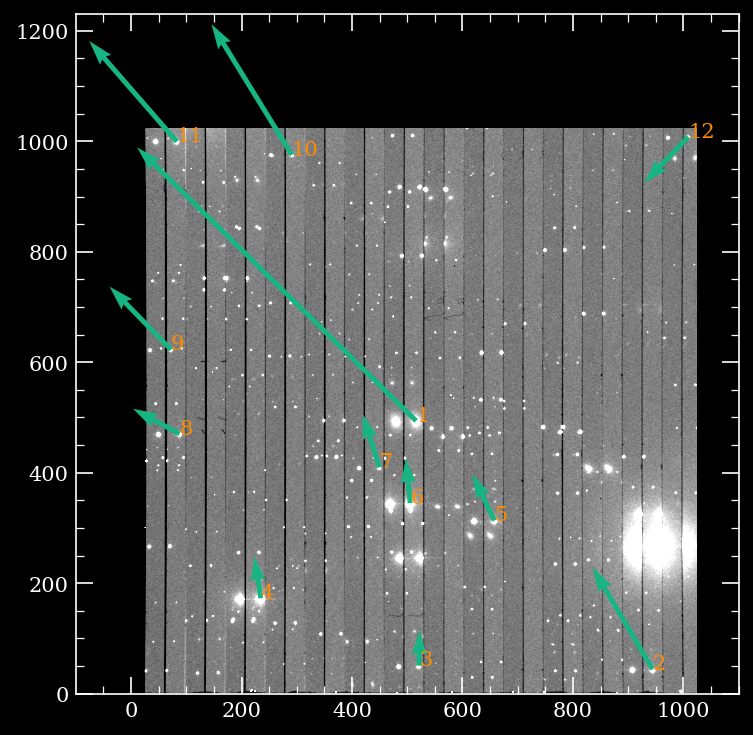

In [50]:
# Misma imagen, pero superpuesta con los vectores de polarización

estre, x, y = np.loadtxt('xy.dat', unpack=True) # posiciones de las estrellas
# Proyecciones del vector de polarización sobre los ejes coordenados
dx = tpol.P * np.cos( tpol.theta* np.pi/180.)
dy = tpol.P * np.sin( tpol.theta* np.pi/180.)

estre_int = estre.astype(int) # arreglo de enteros

#_____________________________________________________________________________________________________
plt.style.use('dark_background')

fig = plt.figure(figsize=(6,6), dpi=150, facecolor='k')
plt.imshow(data, 
           vmin = valor_min, 
           vmax = valor_max, 
           origin='lower', cmap='gray')

plt.quiver(x, y, dx, dy, scale_units = 'xy', color = '#17B583', scale = 0.01) # vectores Polarización

# para poner etiquetas a los vectores
for nom in estre_int:
    posx = x[nom-1]
    posy = y[nom-1]
    plt.text(posx, posy, str(nom), fontsize=10, c='darkorange')
        
plt.xlim(-100,1100)
plt.ylim(0, 1230)
plt.show()

In [ ]:
# Calculamos la P media, el tita medio y sus desviación std, no teniendo en cuenta los objetos 1 y 12:
tpol.drop(1,  inplace=True) #sin el inplace no queda guardado el cambio
tpol.drop(12, inplace=True)
print('P=',tpol.P.mean(),'+-', tpol.P.std(),',theta=', tpol.theta.mean(),'+-', tpol.theta.std())

P= 1.403761446321879 +- 0.774331276966658 ,theta= 116.44781674783073 +- 19.51210073979064


#### 2. En el archivo $\texttt{NGC6250\_pol.dat}$ se encuentran las medidas de polarización en las bandas fotométricas UBVRI de cuatro estrellas del cúmulo abierto NGC 6250. Verifique si es posible ajustar  la ley de Serkowski a dichas medidas. Cuando sea posible, obtenga los valores de la polarización máxima y su correspondiente longitud de onda, para cada caso. ¿Qué puede decir acerca del origen de la polarización medida?

#### En la ley de Serkowski, adopte un valor de $k = 1.15$ (típico para el medio interestelar en nuestra galaxia).

In [3]:
pol6250 = pd.read_csv('NGC6250_pol.dat', sep='\s+', header=None, comment='#',
                     names = ['fil', 'lam', 'P1', 'eP1', 'P3', 'eP3', 'P18', 'eP18', 'P19', 'eP19', 'P25', 'eP25'])
pol6250

,fil,lam,P1,eP1,P3,eP3,P18,eP18,P19,eP19,P25,eP25
0,U,3600,1.37,0.16,1.45,0.16,1.43,0.25,1.04,0.28,1.71,0.47
1,B,4400,1.56,0.14,1.64,0.19,2.00,0.22,1.02,0.21,1.93,0.12
2,V,5300,1.66,0.19,1.85,0.24,1.70,0.20,1.35,0.14,1.96,0.27
3,R,6900,1.67,0.14,1.78,0.17,2.31,0.14,1.03,0.14,1.87,0.20
4,I,8300,1.43,0.16,1.65,0.25,1.67,0.21,0.70,0.17,1.64,0.27


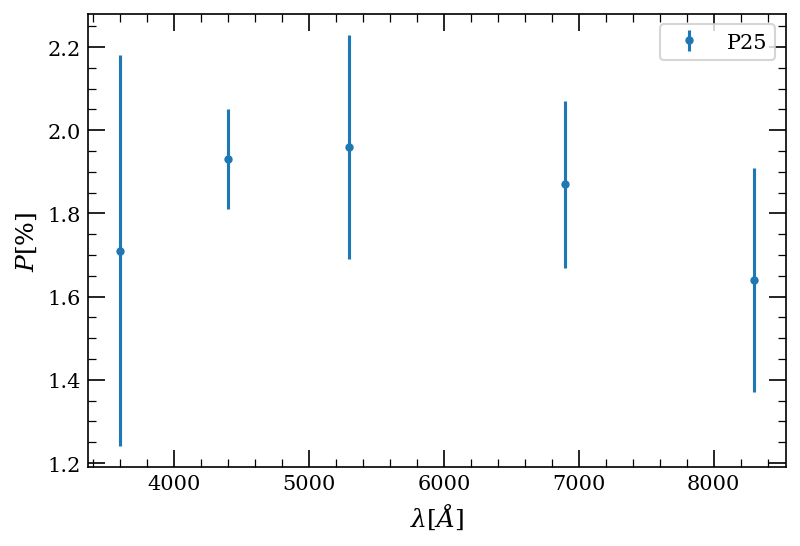

In [15]:
fig = plt.figure(figsize=(6,4), dpi=150)

# plt.errorbar(pol6250.lam, pol6250.P1, yerr= pol6250.eP1, fmt = '.', label='P1')
# plt.errorbar(pol6250.lam, pol6250.P3, yerr= pol6250.eP3, fmt = '.', label='P3')
# plt.errorbar(pol6250.lam, pol6250.P18, yerr= pol6250.eP18, fmt = '.', label='P18')
# plt.errorbar(pol6250.lam, pol6250.P19, yerr= pol6250.eP19, fmt = '.', label='P19')
plt.errorbar(pol6250.lam, pol6250.P25, yerr= pol6250.eP25, fmt = '.', label='P25')

plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()

In [ ]:
# Función para el ajuste: Ley de Serkowsky
def PS(lam,pmax,lmax) :
    k=1.15
    polariza = pmax*np.exp(-k*(np.log(lmax/lam))**2)
    return polariza

# Vector sobre la cual muestrear
longon = np.linspace(3500.,8500.,100)

1.7062720690040971 0.018282209762172118
5692.50123430231 0.018282209762172118


1.7062720690040971 0.018282209762172118
5692.50123430231 0.018282209762172118


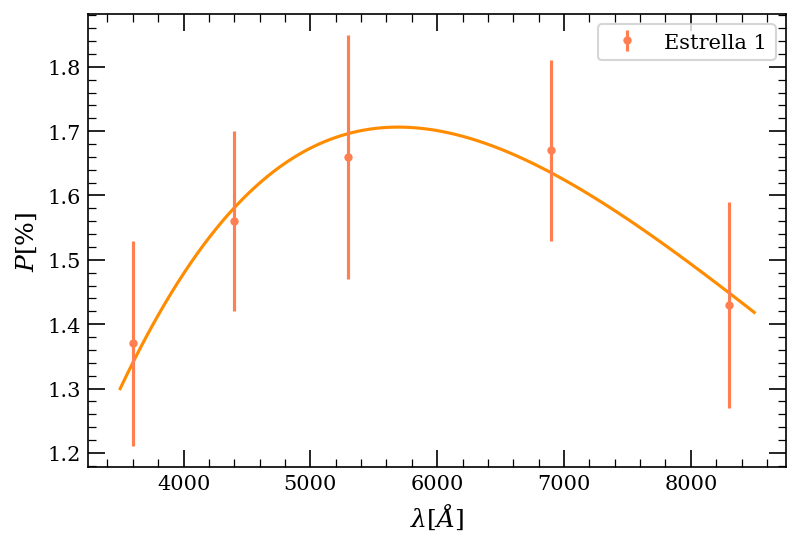

In [24]:
# Ajustamos P1
# Es necesario darle valores iniciales a curve_fit

coef, cov = curve_fit(PS, pol6250.lam, pol6250.P1, sigma=pol6250.eP1, # el sigma marca los errores, p0 marca los valores iniciales (gráfico anterior)
                      p0 = [1.7,6000]) # valores iniciales
pmax1 = coef[0]
lmax1 = coef[1]
err_pmax1 = np.sqrt(cov[0,0])
err_lmax1 = np.sqrt(cov[0,0])
print(pmax1, err_pmax1)
print(lmax1, err_lmax1)

# Graficamos las observaciones y el ajuste:

fig = plt.figure(figsize=(6,4), dpi=150)

plt.plot(longon, PS(longon, pmax1, lmax1), c='darkorange')
plt.errorbar(pol6250.lam, pol6250.P1, yerr= pol6250.eP1, fmt = '.',c='coral', label='Estrella 1')

plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()
plt.show()
# la ley de serkowsky representa a la polarización debida al medio interestelar. Si la polarización sigue esta curva, podemos decir que
# la polarización en esa estrella es debida a este factor. En otro caso no lo sería.

1.8541529274618282 0.022999643946924372
5835.6518954490975 0.022999643946924372


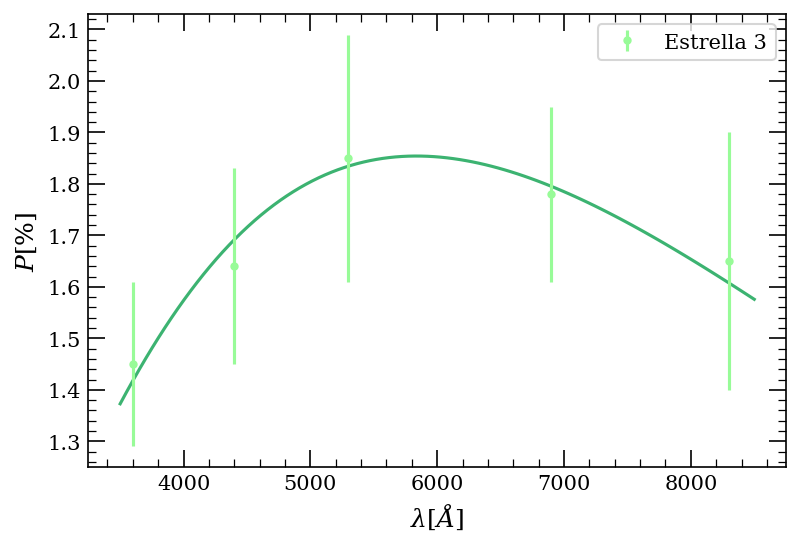

In [25]:
# Ajustamos P3

coef, cov = curve_fit(PS, pol6250.lam, pol6250.P3, sigma=pol6250.eP3,
                      p0 = [1.9,6000])
pmax1 = coef[0]
lmax1 = coef[1]
err_pmax1 = np.sqrt(cov[0,0])
err_lmax1 = np.sqrt(cov[0,0])
print(pmax1, err_pmax1)
print(lmax1, err_lmax1)

# Graficamos las observaciones y el ajuste:

fig = plt.figure(figsize=(6,4), dpi=150)

plt.plot(longon, PS(longon, pmax1, lmax1), c='mediumseagreen')
plt.errorbar(pol6250.lam, pol6250.P3, yerr= pol6250.eP3, fmt = '.',c='palegreen', label='Estrella 3')

plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()
plt.show()

2.111995474778425 0.1498061909892455
6305.807040977109 0.1498061909892455


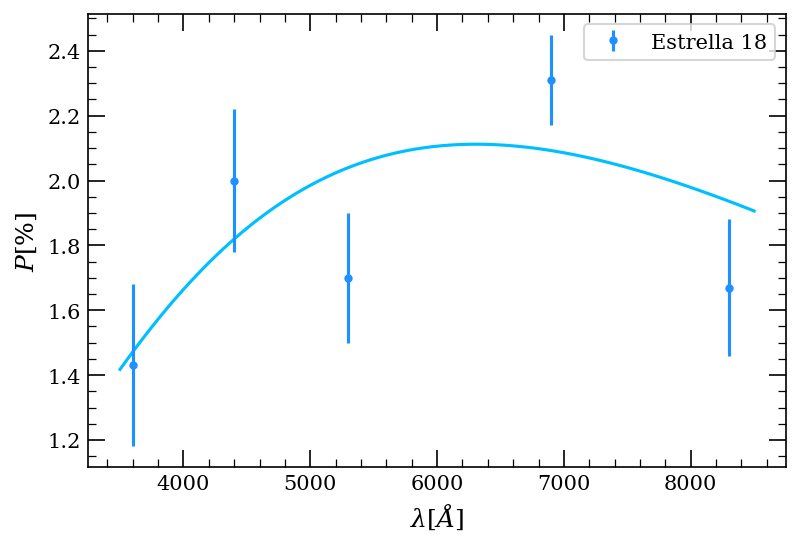

In [26]:
# Ajustamos P18 POLARIZADA NO POR MIE

coef, cov = curve_fit(PS, pol6250.lam, pol6250.P18, sigma=pol6250.eP18,
                      p0 = [2.1,6000])
pmax1 = coef[0]
lmax1 = coef[1]
err_pmax1 = np.sqrt(cov[0,0])
err_lmax1 = np.sqrt(cov[0,0])
print(pmax1, err_pmax1)
print(lmax1, err_lmax1)

# Graficamos las observaciones y el ajuste:

fig = plt.figure(figsize=(6,4), dpi=150)

plt.plot(longon, PS(longon, pmax1, lmax1), c='deepskyblue')
plt.errorbar(pol6250.lam, pol6250.P18, yerr= pol6250.eP18, fmt = '.', c='dodgerblue', label='Estrella 18')


plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()
plt.show()

1.2164668368458937 0.10615288016171015
4653.311768584466 0.10615288016171015


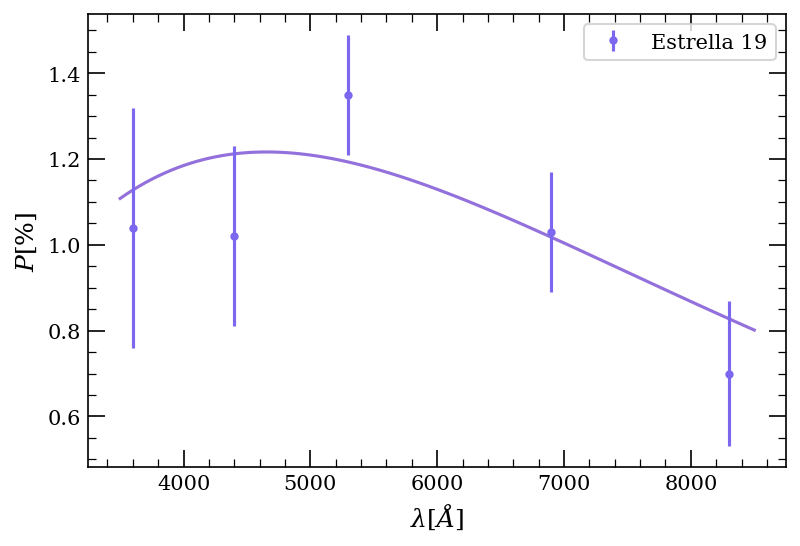

In [29]:
# Ajustamos P19 - Polarizada no por Mie?

coef, cov = curve_fit(PS, pol6250.lam, pol6250.P19, sigma=pol6250.eP19,
                      p0 = [1.3,6000])
pmax1 = coef[0]
lmax1 = coef[1]
err_pmax1 = np.sqrt(cov[0,0])
err_lmax1 = np.sqrt(cov[0,0])
print(pmax1, err_pmax1)
print(lmax1, err_lmax1)

# Graficamos las observaciones y el ajuste:

fig = plt.figure(figsize=(6,4), dpi=150)

plt.plot(longon, PS(longon, pmax1, lmax1), c='mediumpurple')
plt.errorbar(pol6250.lam, pol6250.P19, yerr= pol6250.eP19, fmt = '.', c='mediumslateblue', label='Estrella 19')

plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()
plt.show()

2.0130087099511362 0.012818036323853092
5361.065983380874 0.012818036323853092


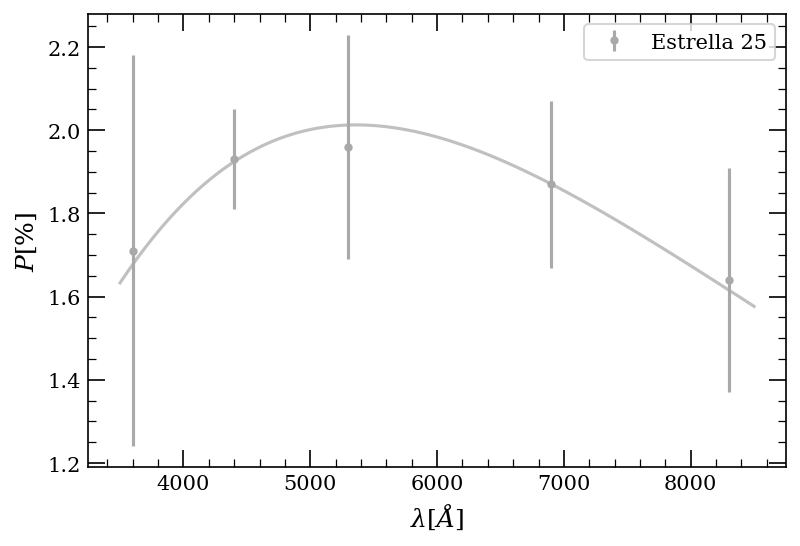

In [38]:
# Ajustamos P25

coef, cov = curve_fit(PS, pol6250.lam, pol6250.P25, sigma=pol6250.eP25,
                      p0 = [1.95,6000])
pmax1 = coef[0]
lmax1 = coef[1]
err_pmax1 = np.sqrt(cov[0,0])
err_lmax1 = np.sqrt(cov[0,0])
print(pmax1, err_pmax1)
print(lmax1, err_lmax1)

# Graficamos las observaciones y el ajuste:

fig = plt.figure(figsize=(6,4), dpi=150)

plt.plot(longon, PS(longon, pmax1, lmax1), c='silver')
plt.errorbar(pol6250.lam, pol6250.P25, yerr= pol6250.eP25, fmt = '.', c='darkgray', label='Estrella 25')

plt.xlabel('$\lambda$[$\AA$]')
plt.ylabel('$P$[%]')
plt.legend()
plt.show()